<a href="https://colab.research.google.com/github/RayCharles8/Tabular-Models/blob/main/IML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# New Section

In [52]:
!ls "/content/drive/MyDrive/ML Project"

 cif_files	    'IML Project.ipynb'   Untitled0.ipynb
 Final_Dataset.csv   Untitled


In [53]:
pwd

'/content/drive/MyDrive/ML Project'

In [54]:
%cd "/content/drive/MyDrive/ML Project"

/content/drive/MyDrive/ML Project


In [55]:
ls

 cif_files/         'IML Project.ipynb'   Untitled0.ipynb
 Final_Dataset.csv   Untitled


In [56]:
!pip install pandas
!pip install pymatgen

In [57]:
import pandas as pd
import numpy as np

In [58]:
df = pd.read_csv("Final_Dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (7071, 17)

Columns:
['mp_material_id', 'mp_formula', 'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'Topological Label', 'label', 'cif']


,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-561491,KNaMg2Si4(O5F)2,C2/m,12,20.0,5.2111,5.309658,5.309658,10.428630,84.307544,84.307544,119.491314,3.333333,2.716,Trivial,0,cif_files/mp-561491.cif
1,mp-863017,RbZnH2Se2BrO6,P2/c,13,26.0,4.0088,6.239946,6.565930,10.950201,77.162171,90.000000,90.000000,4.333333,2.736,Trivial,0,cif_files/mp-863017.cif
2,mp-863023,RbZnH2Se2ClO6,P2/c,13,26.0,4.3352,6.107845,6.536718,10.948379,76.827476,90.000000,90.000000,4.333333,2.752,Trivial,0,cif_files/mp-863023.cif
3,mp-1195661,RbNa2Fe3P4ClO14,C2/c,15,50.0,3.8946,10.883293,10.883293,13.900955,62.105534,62.105534,27.967612,8.333333,2.730,Trivial,0,cif_files/mp-1195661.cif
4,mp-1205129,Na3LiTi2Si4(HO4)4,C2/c,15,60.0,3.5603,5.279085,8.674130,15.079773,106.714811,89.629933,90.000000,10.000000,2.610,Trivial,0,cif_files/mp-1205129.cif


In [59]:
class_counts = df["label"].value_counts()

print("Number of samples per class:\n")
print(class_counts)

print("\nClass ratio (percentage):\n")
print(df["label"].value_counts(normalize=True) * 100)

Number of samples per class:

label
0    3699
1    3372
Name: count, dtype: int64

Class ratio (percentage):

label
0    52.312261
1    47.687739
Name: proportion, dtype: float64


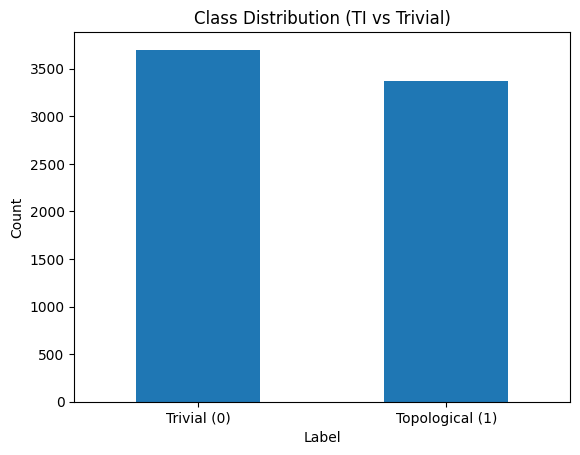

In [60]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")
plt.title("Class Distribution (TI vs Trivial)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Trivial (0)", "Topological (1)"], rotation=0)
plt.show()

In [61]:
features = [
    "Band Gap",
    "a", "b", "c",
    "alpha", "beta", "gamma",
    "spacegroup",              # categorical
    "spacegroup_number",       # categorical
    "number of atoms",
    "Z",
    "electronegativity"
]

target = "label"

df_model = df[features + [target]].dropna()

print("Cleaned shape:", df_model.shape)

Cleaned shape: (7071, 13)


In [62]:
# Encode spacegroup as categorical codes
df_model["spacegroup"] = df_model["spacegroup"].astype("category").cat.codes

X = df_model.drop(columns=[target])
y = df_model[target]

print("Final feature shape:", X.shape)

Final feature shape: (7071, 12)


In [63]:
!pip install scikit-learn
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

In [64]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [65]:
# Split temp → 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,  # 0.5 of 30% ≈ 15%
    stratify=y_temp,
    random_state=42
)

In [66]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4949, 12)
Validation: (1061, 12)
Test: (1061, 12)


In [100]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
label
0    0.523136
1    0.476864
Name: proportion, dtype: float64

Validation distribution:
label
0    0.523091
1    0.476909
Name: proportion, dtype: float64

Test distribution:
label
0    0.523091
1    0.476909
Name: proportion, dtype: float64


In [68]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [69]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
print("Random Forest training complete.")

Random Forest training complete.


In [70]:
def evaluate(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]

    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

evaluate(rf, X_train, y_train, "Train")
evaluate(rf, X_val, y_val, "Validation")
evaluate(rf, X_test, y_test, "Test")


Train Performance
Accuracy: 0.9913113760355627
F1-score: 0.990899470899471
ROC-AUC: 0.999848691661593
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2589
           1       0.99      0.99      0.99      2360

    accuracy                           0.99      4949
   macro avg       0.99      0.99      0.99      4949
weighted avg       0.99      0.99      0.99      4949


Validation Performance
Accuracy: 0.8680490103675778
F1-score: 0.8619329388560157
ROC-AUC: 0.9412972260798348
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       555
           1       0.86      0.86      0.86       506

    accuracy                           0.87      1061
   macro avg       0.87      0.87      0.87      1061
weighted avg       0.87      0.87      0.87      1061


Test Performance
Accuracy: 0.8661639962299718
F1-score: 0.8565656565656565
ROC-AUC: 0.9325695260477869
              precision    re

In [71]:
!pip install shap
import shap
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test)

In [73]:
import shap

explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf(X_test)

# Select class 1 (Topological Insulator)
shap_class1 = shap_values_rf[:, :, 1]


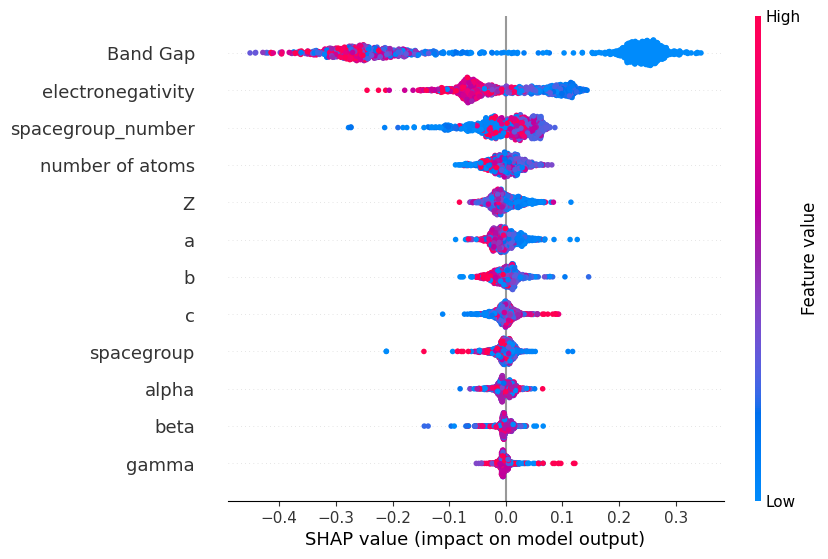

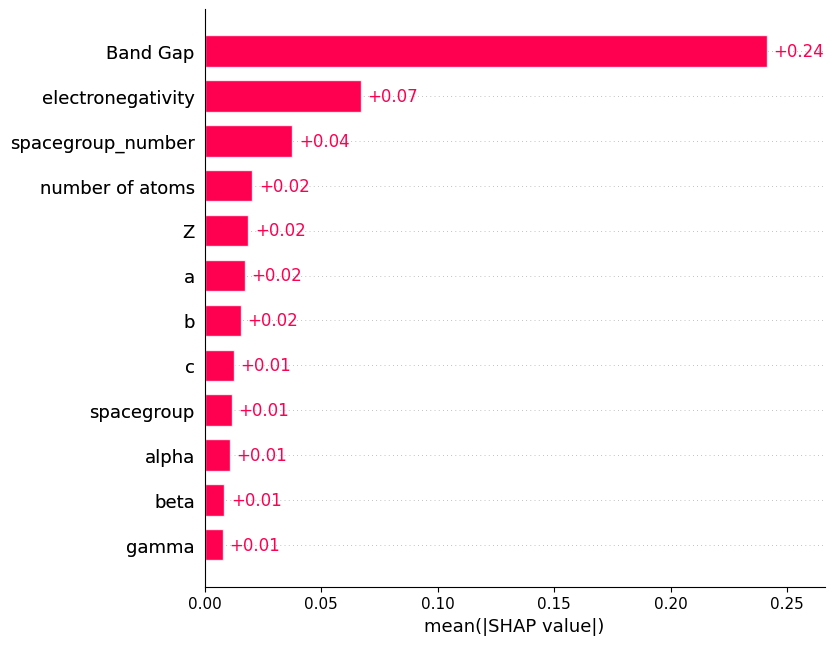

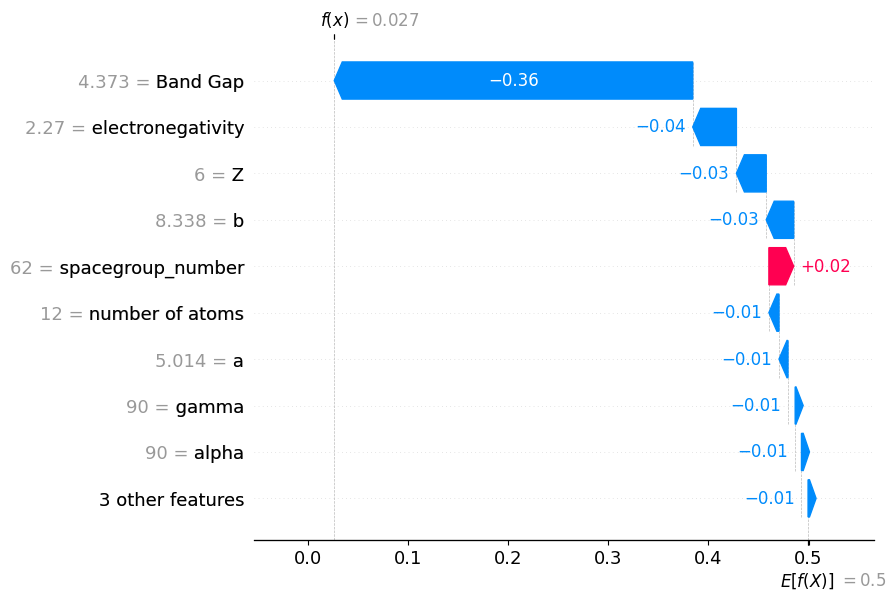

In [74]:
shap.plots.beeswarm(shap_class1, max_display=15)
shap.plots.bar(shap_class1, max_display=15)
shap.plots.waterfall(shap_class1[0])

In [75]:
from xgboost import XGBClassifier

In [101]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Check shapes and class distribution
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train: (4949, 12) Validation: (1061, 12) Test: (1061, 12)

Train distribution:
 label
0    0.523136
1    0.476864
Name: proportion, dtype: float64

Validation distribution:
 label
0    0.523091
1    0.476909
Name: proportion, dtype: float64

Test distribution:
 label
0    0.523091
1    0.476909
Name: proportion, dtype: float64


In [77]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("XGBoost training complete.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:53:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training complete.


In [78]:
def evaluate_model(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]

    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

# Evaluate
evaluate_model(xgb, X_train, y_train, "Train")
evaluate_model(xgb, X_val, y_val, "Validation")
evaluate_model(xgb, X_test, y_test, "Test")


Train Performance
Accuracy: 0.9688826025459689
F1-score: 0.9677689409794893
ROC-AUC: 0.9969794796760741
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2589
           1       0.96      0.98      0.97      2360

    accuracy                           0.97      4949
   macro avg       0.97      0.97      0.97      4949
weighted avg       0.97      0.97      0.97      4949


Validation Performance
Accuracy: 0.885956644674835
F1-score: 0.8810226155358899
ROC-AUC: 0.954207171598476
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       555
           1       0.88      0.89      0.88       506

    accuracy                           0.89      1061
   macro avg       0.89      0.89      0.89      1061
weighted avg       0.89      0.89      0.89      1061


Test Performance
Accuracy: 0.883129123468426
F1-score: 0.8764940239043825
ROC-AUC: 0.9458409001887261
              precision    rec

In [79]:
explainer_xgb = shap.TreeExplainer(xgb)
X_sample = X_test # Use the entire X_test for explanation
shap_values_xgb = explainer_xgb(X_sample)

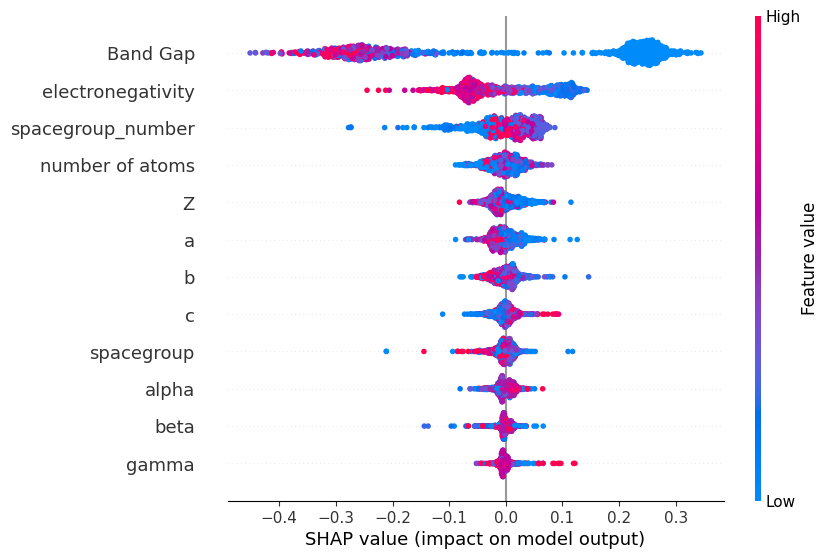

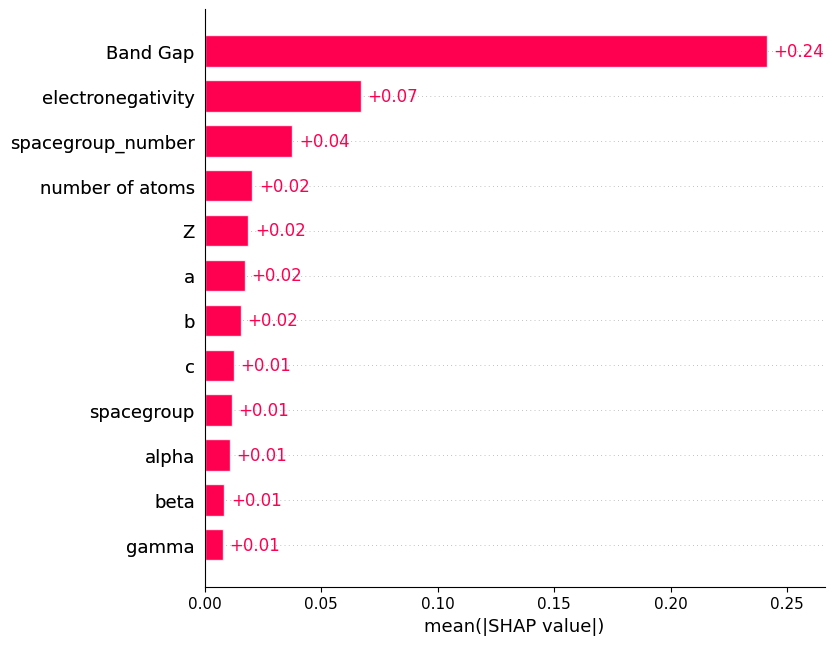

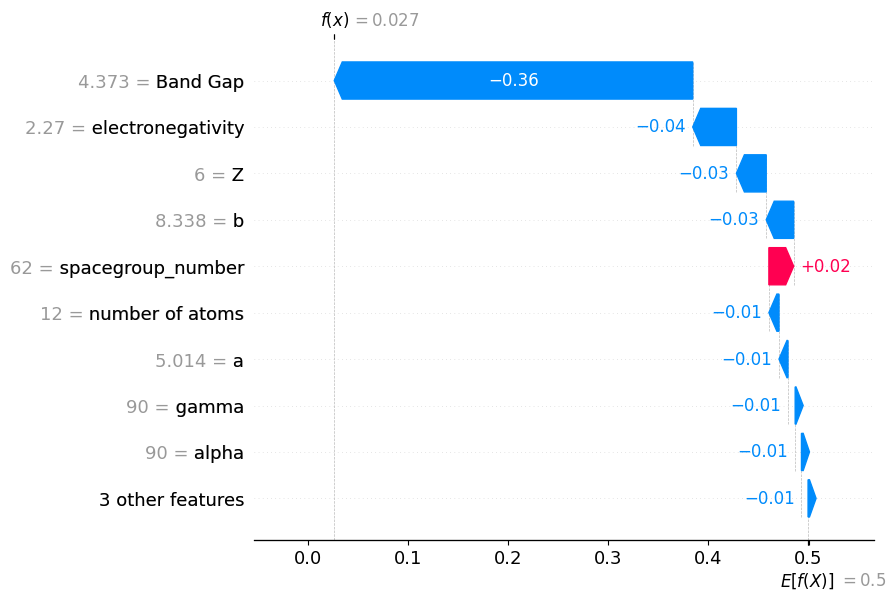

In [80]:
shap.plots.beeswarm(shap_class1, max_display=15)
shap.plots.bar(shap_class1, max_display=15)
shap.plots.waterfall(shap_class1[0])

In [82]:
X_test_subset = X_test
explainer_xgb = shap.TreeExplainer(xgb)
shap_values = explainer_xgb(X_test_subset)

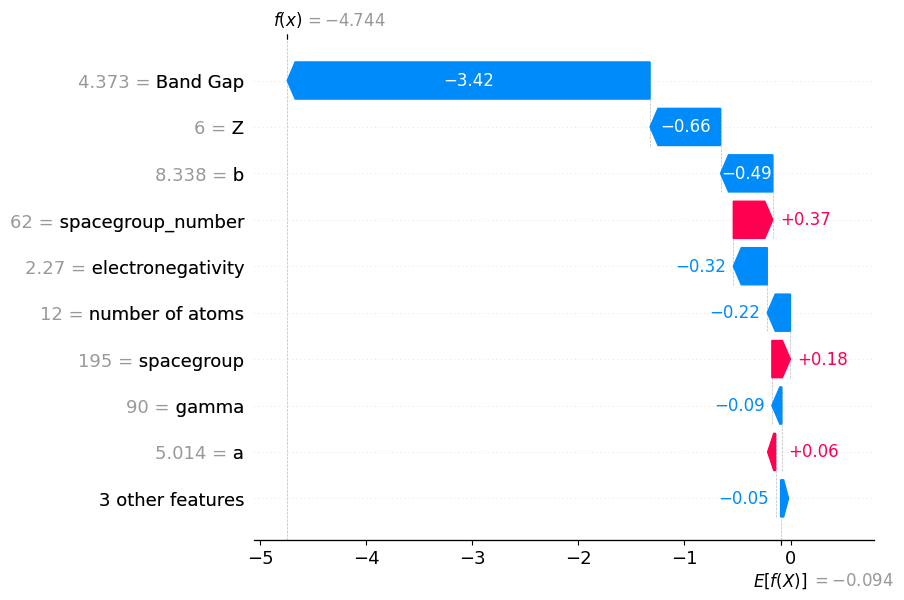

In [84]:
# Pick one test sample
sample = X_test.iloc[[0]]
shap_values_sample = explainer_xgb(sample)

# Waterfall plot
shap.plots.waterfall(shap_values_sample[0])

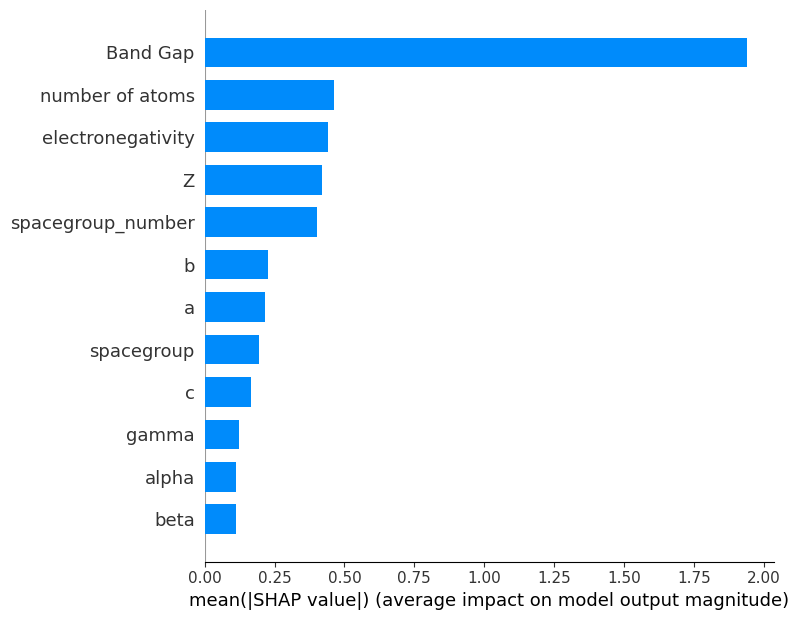

In [87]:

# Global feature importance
shap.summary_plot(shap_values_xgb.values, X_test, plot_type="bar")

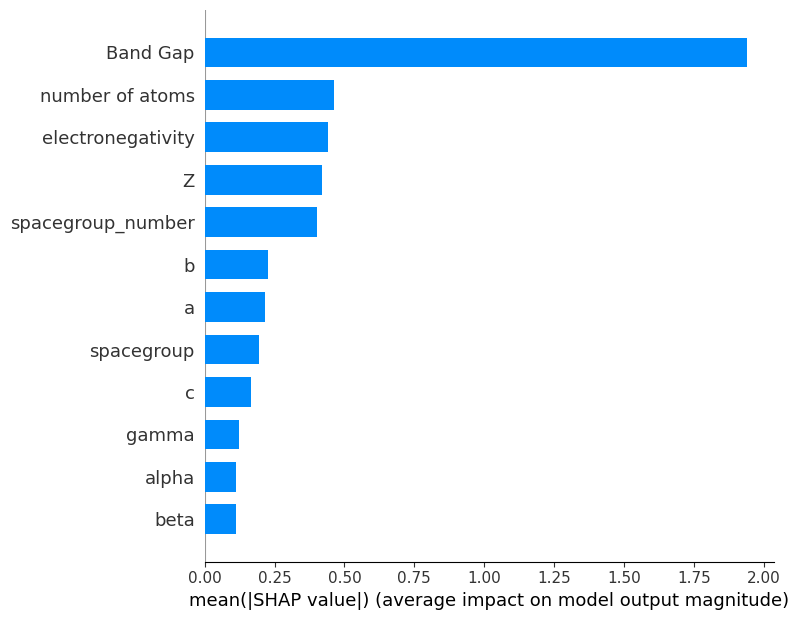

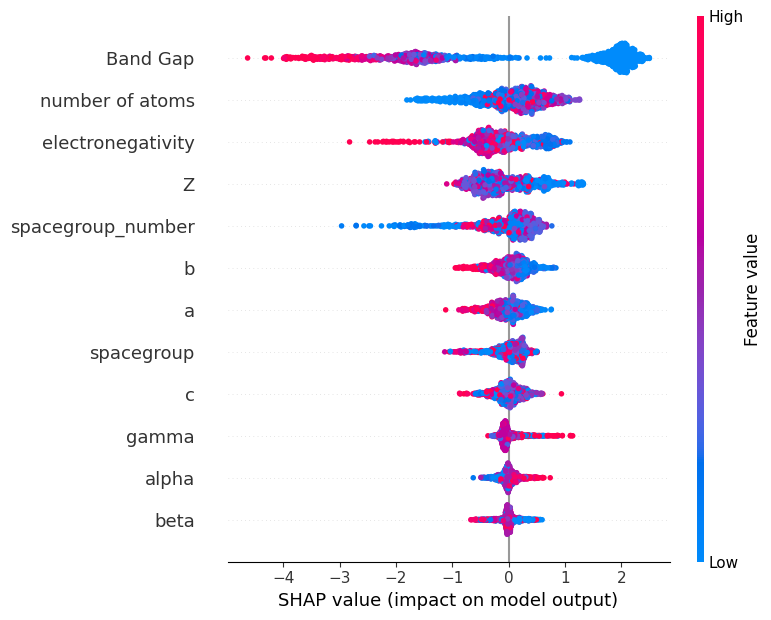

In [89]:
# Bar plot
shap.summary_plot(shap_values_xgb, features=X_test, plot_type="bar", max_display=20)

# Beeswarm plot
shap.summary_plot(shap_values_xgb, features=X_test, max_display=20)

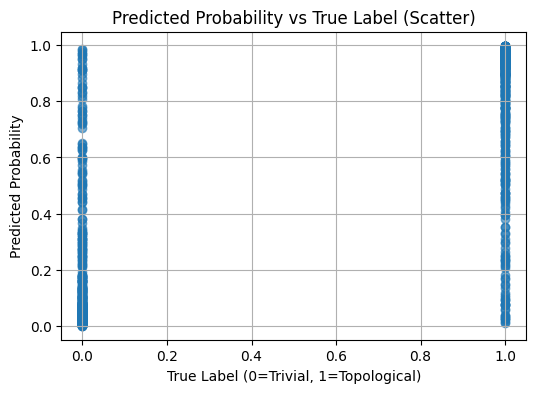

In [91]:
import matplotlib.pyplot as plt

# Predicted probabilities for positive class
y_prob = xgb.predict_proba(X_test)[:,1]
y_true = y_test.values

plt.figure(figsize=(6,4))
plt.scatter(y_true, y_prob, alpha=0.6)
plt.xlabel("True Label (0=Trivial, 1=Topological)")
plt.ylabel("Predicted Probability")
plt.title("Predicted Probability vs True Label (Scatter)")
plt.grid(True)
plt.show()

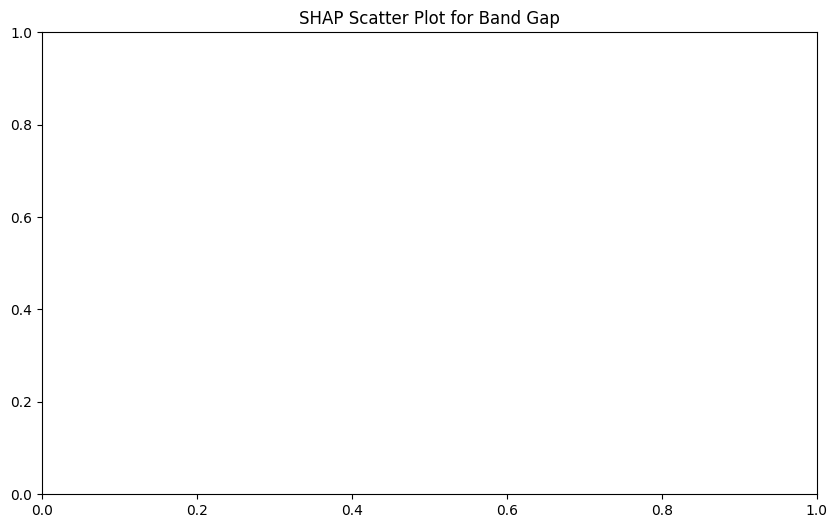

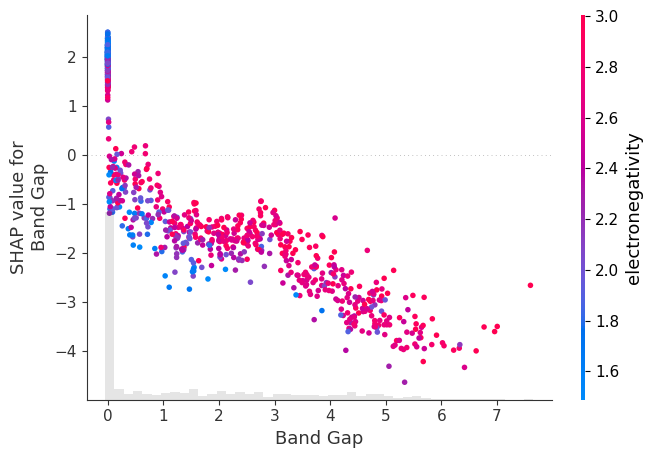

In [92]:

# We choose 'Band_Gap' as it is a key physical descriptor for topological insulators
feature_to_plot = 'Band_Gap' if 'Band_Gap' in X_test.columns else X_test.columns[0]
plt.figure(figsize=(10, 6))
plt.title(f'SHAP Scatter Plot for {feature_to_plot}')
shap.plots.scatter(shap_values_xgb[:, feature_to_plot], color=shap_values_xgb)
plt.show()

In [107]:
rf_metrics = extract_metrics(rf, X_test, y_test, "RandomForest")
xgb_metrics = extract_metrics(xgb, X_test, y_test, "XGBoost")

metrics_df = pd.DataFrame([rf_metrics, xgb_metrics])

print("Model Performance Comparison on Test Set:")
display(metrics_df)

Model Performance Comparison on Test Set:


,model_name,accuracy,precision,f1_score,roc_auc
0,RandomForest,0.866164,0.876033,0.856566,0.932570
1,XGBoost,0.883129,0.883534,0.876494,0.945841


/tmp/ipykernel_556/2521555137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_556/2521555137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_556/2521555137.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_556/2521555137.py:11: FutureWarning: 

Passing `palette` with

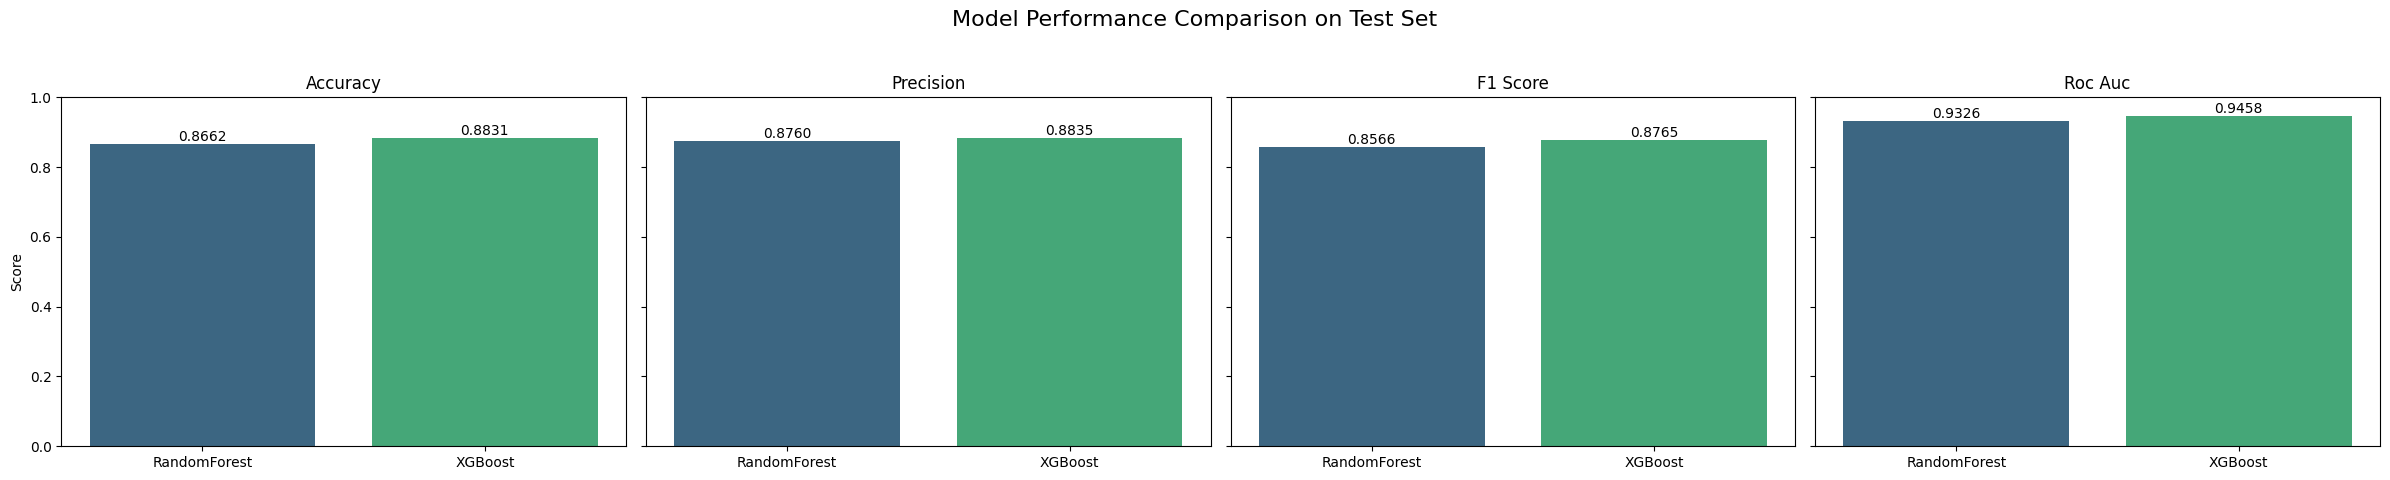

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['accuracy', 'precision', 'f1_score', 'roc_auc'] # Added precision here
model_names = metrics_df['model_name'].tolist()

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 5), sharey=True) # Adjusted figsize for 4 plots
fig.suptitle('Model Performance Comparison on Test Set', fontsize=16)

for i, metric in enumerate(metrics):
    sns.barplot(x='model_name', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
    axes[i].set_title(metric.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score' if i == 0 else '')
    axes[i].set_ylim(0, 1) # Explicitly set y-axis from 0 to 1

    # Add numerical labels on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The bar charts clearly visualize the performance of RandomForest and XGBoost models across Accuracy, F1-score, and ROC-AUC. As observed, the XGBoost model generally exhibits slightly higher scores in all three metrics, reinforcing its superior performance compared to RandomForest on this dataset.